# Enterprise Data Architecture & Reconciliation

## The Scenario
You are a Senior Data Analyst at a massive FinTech company. The Data Engineering team is on vacation, and the CFO needs the Q1-Q4 Financial Audit Dashboard by Friday.

You have been given access to three separate, messy systems:
1. **The HR Database (`enterprise_database.db`):** A SQL database containing user accounts. *Warning: It contains historical logs, meaning users appear multiple times. You only want their most recent status.*
2. **The Server Logs (`server_logs.txt`):** 100,000 raw text logs. The transaction data is trapped inside strings.
3. **The Finance Server (`daily_exchange_rates.csv`):** A list of daily EUR to USD exchange rates. *Warning: The financial market is closed on weekends, so weekend dates have missing exchange rates.*

## Your Mission
You must architect a Python pipeline to extract, clean, merge, and visualize this data.

**Requirements for Passing:**
1. **Advanced SQL:** Extract only "Active" users from the database using the most recent `updated_at` timestamp.
2. **String Manipulation (Regex):** Extract the Date, User ID, Product ID, and Euro Value from the raw text logs. Filter out rows labeled "ERROR".
3. **Temporal Joins:** Join the transactions to the exchange rate table based on the exact day. You must forward-fill the weekend exchange rates so transactions don't drop out.
4. **Efficiency:** Your code must run on all 100,000 rows in under 2 minutes. No `for` loops allowed in Pandas.
5. **Dashboard:** Build visualizations showing Total USD Revenue by Month and Top 5 Most Valuable Customers.

In [11]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to 'enterprise_database.db'
# 2. Write a SQL query (using Window Functions or Subqueries) to get the most
#    recent status for each user.
# 3. Only keep users whose latest status is 'Active'.
# 4. Load the result into a Pandas DataFrame called 'df_active_users'.

# [WRITE YOUR SQL AND PYTHON CODE HERE]
# Connect to database
conn = sqlite3.connect("enterprise_database (1).db")

# SQL query to get the latest record for each user
query = """
WITH ranked_users AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY user_id
               ORDER BY updated_at DESC
           ) AS rn
    FROM users
)
SELECT user_id, name, status, updated_at
FROM ranked_users
WHERE rn = 1
AND status = 'Active';
"""

# Load the result into a Pandas DataFrame
df_active_users = pd.read_sql_query(query, conn)

# Display first 5 records
df_active_users.head()

,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


In [14]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# 1. Load 'server_logs.txt' into a DataFrame.
# 2. Drop any rows where the log contains the word "ERROR".
# 3. Use Pandas string methods (.str.extract()) or Python Regex to pull the
#    Date, User ID, Product ID, and Euro Value out of the raw text string.
# 4. Save this cleaned data to a new DataFrame called 'extracted_data'.

# [WRITE YOUR REGEX AND CLEANING CODE HERE]
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

import pandas as pd
import re

# 1. Load server_logs.txt
with open("server_logs (1).txt", "r", encoding="utf-8") as file:
    logs = file.readlines()

# Create DataFrame
logs_df = pd.DataFrame(logs, columns=["raw_log"])

# Remove extra spaces/new lines
logs_df["raw_log"] = logs_df["raw_log"].str.strip()

# Display first 5 logs
logs_df.head()

,raw_log
0,Raw_Server_Log
1,"""[2023-03-15 00:00:00] INFO: Transaction proce..."
2,"""[2023-09-09 00:00:00] ERROR: Transaction proc..."
3,"""[2023-05-09 00:00:00] INFO: Transaction proce..."
4,"""[2023-10-21 00:00:00] INFO: Transaction proce..."


In [16]:
# Display 5 complete log lines
for log in clean_logs["raw_log"].head(5):
    print(log)

"[2023-03-15 00:00:00] INFO: Transaction processed. payload={""u"":""U-19484"", ""item_code"":""PRD-874"", ""eur_val"":3404.44}"
"[2023-05-09 00:00:00] INFO: Transaction processed. payload={""u"":""U-18932"", ""item_code"":""PRD-905"", ""eur_val"":3406.21}"
"[2023-10-21 00:00:00] INFO: Transaction processed. payload={""u"":""U-15882"", ""item_code"":""PRD-284"", ""eur_val"":164.08}"
"[2023-01-10 00:00:00] INFO: Transaction processed. payload={""u"":""U-22781"", ""item_code"":""PRD-665"", ""eur_val"":26.8}"
"[2023-05-23 00:00:00] INFO: Transaction processed. payload={""u"":""U-13348"", ""item_code"":""PRD-589"", ""eur_val"":4964.77}"


In [17]:
# Extract Date, User ID, Product ID and Euro Value

extracted_data = clean_logs["raw_log"].str.extract(
    r'\[(?P<Date>\d{4}-\d{2}-\d{2})\s+\d{2}:\d{2}:\d{2}\].*?'
    r'""u"":""(?P<User_ID>U-\d+)".*?'
    r'""item_code"":""(?P<Product_ID>PRD-\d+)".*?'
    r'""eur_val"":(?P<Euro_Value>[\d.]+)',
    expand=True
)

# Convert Euro Value to numeric
extracted_data["Euro_Value"] = pd.to_numeric(
    extracted_data["Euro_Value"],
    errors="coerce"
)

# Display first 5 records
extracted_data.head()

,Date,User_ID,Product_ID,Euro_Value
1,2023-03-15,U-19484,PRD-874,3404.44
3,2023-05-09,U-18932,PRD-905,3406.21
4,2023-10-21,U-15882,PRD-284,164.08
5,2023-01-10,U-22781,PRD-665,26.80
6,2023-05-23,U-13348,PRD-589,4964.77


In [18]:
# Save the extracted data for further processing

extracted_data.to_csv("extracted_data.csv", index=False)

# Check the cleaned data
print("Extracted data saved successfully!")
print("Total records:", len(extracted_data))

extracted_data.head()

Extracted data saved successfully!
Total records: 94902


,Date,User_ID,Product_ID,Euro_Value
1,2023-03-15,U-19484,PRD-874,3404.44
3,2023-05-09,U-18932,PRD-905,3406.21
4,2023-10-21,U-15882,PRD-284,164.08
5,2023-01-10,U-22781,PRD-665,26.80
6,2023-05-23,U-13348,PRD-589,4964.77


In [20]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

# 1. Load 'daily_exchange_rates.csv' into a DataFrame.
# 2. Handle the missing weekend data using a method like .fillna(method='ffill')
#    so Friday's rate rolls over to Saturday and Sunday.
# 3. Merge your cleaned logs with the exchange rates by Date.
# 4. Merge that result with your active SQL users by User ID.
# 5. Calculate a new column called 'USD_Revenue' (Euro Value * Exchange Rate).
# 6. Save the final merged table as 'df_final'.

# [WRITE YOUR MERGING AND MATH CODE HERE]
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

import pandas as pd

# 1. Load daily exchange rates
exchange_rates = pd.read_csv("daily_exchange_rates (1).csv")

# Check the structure
print("Shape:", exchange_rates.shape)
print("\nColumns:")
print(exchange_rates.columns.tolist())

# Display first 5 rows
exchange_rates.head()

Shape: (365, 2)

Columns:
['Date', 'EUR_to_USD']


,Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292


In [21]:
# Convert Date column to datetime
exchange_rates["Date"] = pd.to_datetime(exchange_rates["Date"])

# Check missing exchange rates
print("Missing exchange rates before filling:",
      exchange_rates["EUR_to_USD"].isna().sum())

# Forward-fill missing values
exchange_rates["EUR_to_USD"] = exchange_rates["EUR_to_USD"].ffill()

# Check again
print("Missing exchange rates after filling:",
      exchange_rates["EUR_to_USD"].isna().sum())

# Display rows around a weekend
exchange_rates.head(10)

Missing exchange rates before filling: 104
Missing exchange rates after filling: 0


,Date,EUR_to_USD
0,2023-01-01,1.124836
1,2023-01-02,1.093087
2,2023-01-03,1.132384
3,2023-01-04,1.176151
4,2023-01-05,1.088292
5,2023-01-06,1.088292
6,2023-01-07,1.088292
7,2023-01-08,1.138372
8,2023-01-09,1.076526
9,2023-01-10,1.127128


In [22]:
# Convert Date in extracted_data to datetime
extracted_data["Date"] = pd.to_datetime(extracted_data["Date"])

# 3. Merge cleaned logs with exchange rates by Date
merged_data = pd.merge(
    extracted_data,
    exchange_rates,
    on="Date",
    how="left"
)

# Check the result
print("Merged data shape:", merged_data.shape)

merged_data.head()

Merged data shape: (94902, 5)


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983
2,2023-10-21,U-15882,PRD-284,164.08,1.075350
3,2023-01-10,U-22781,PRD-665,26.80,1.127128
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626


In [23]:
# 4. Merge transaction data with active SQL users

df_final = pd.merge(
    merged_data,
    df_active_users,
    left_on="User_ID",
    right_on="user_id",
    how="inner"
)

# Calculate USD Revenue
df_final["USD_Revenue"] = (
    df_final["Euro_Value"] * df_final["EUR_to_USD"]
)

# Display final result
print("Final data shape:", df_final.shape)

df_final.head()

Final data shape: (53899, 10)


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,user_id,name,status,updated_at,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,U-19484,User_U-19484,Active,2023-01-11 14:00:00,4011.220772
1,2023-10-21,U-15882,PRD-284,164.08,1.075350,U-15882,User_U-15882,Active,2023-01-16 14:00:00,176.443420
2,2023-01-10,U-22781,PRD-665,26.80,1.127128,U-22781,User_U-22781,Active,2023-01-07 14:00:00,30.207030
3,2023-10-20,U-22062,PRD-363,48.63,1.075350,U-22062,User_U-22062,Active,2023-01-05 14:00:00,52.294268
4,2023-12-02,U-22146,PRD-223,960.60,1.066142,U-22146,User_U-22146,Active,2023-01-18 14:00:00,1024.135923


In [24]:
# Save the final reconciled data

df_final.to_csv("df_final.csv", index=False)

print("Final merged table saved successfully!")
print("Total final records:", len(df_final))

df_final.head()

Final merged table saved successfully!
Total final records: 53899


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,user_id,name,status,updated_at,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,U-19484,User_U-19484,Active,2023-01-11 14:00:00,4011.220772
1,2023-10-21,U-15882,PRD-284,164.08,1.075350,U-15882,User_U-15882,Active,2023-01-16 14:00:00,176.443420
2,2023-01-10,U-22781,PRD-665,26.80,1.127128,U-22781,User_U-22781,Active,2023-01-07 14:00:00,30.207030
3,2023-10-20,U-22062,PRD-363,48.63,1.075350,U-22062,User_U-22062,Active,2023-01-05 14:00:00,52.294268
4,2023-12-02,U-22146,PRD-223,960.60,1.066142,U-22146,User_U-22146,Active,2023-01-18 14:00:00,1024.135923


In [27]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

# 1. Group the data in 'df_final' to calculate Total USD Revenue by Month.
# 2. Group the data to find the Top 5 Most Valuable Customers by Total USD spent.
# 3. Use Matplotlib or Seaborn to generate two charts side-by-side:
#    - Chart 1: A Line Chart or Bar Chart showing Revenue by Month.
#    - Chart 2: A Bar Chart showing the Top 5 Customers.
# 4. Ensure your charts have titles, clean axes, and are easy to read.

# [WRITE YOUR VISUALIZATION CODE HERE]
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

import pandas as pd
import matplotlib.pyplot as plt

# Make sure Date is in datetime format
df_final["Date"] = pd.to_datetime(df_final["Date"])

# 1. Total USD Revenue by Month
df_final["Month"] = df_final["Date"].dt.to_period("M").astype(str)

monthly_revenue = (
    df_final.groupby("Month")["USD_Revenue"]
    .sum()
    .reset_index()
)

# 2. Top 5 Most Valuable Customers
top_customers = (
    df_final.groupby("User_ID")["USD_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Display results
print("Monthly Revenue:")
display(monthly_revenue)


Monthly Revenue:


,Month,USD_Revenue
0,2023-01,1.284176e+07
1,2023-02,1.143613e+07
2,2023-03,1.234893e+07
3,2023-04,1.201538e+07
4,2023-05,1.233364e+07
5,2023-06,1.208436e+07
6,2023-07,1.244416e+07
7,2023-08,1.281273e+07
8,2023-09,1.222895e+07
9,2023-10,1.250133e+07


In [28]:
# Display Top 5 Most Valuable Customers

print("Top 5 Most Valuable Customers:")
display(top_customers)

Top 5 Most Valuable Customers:


,User_ID,USD_Revenue
0,U-06582,40050.988262
1,U-23313,39555.806629
2,U-03805,39529.945085
3,U-20018,38649.965242
4,U-06489,38629.142146


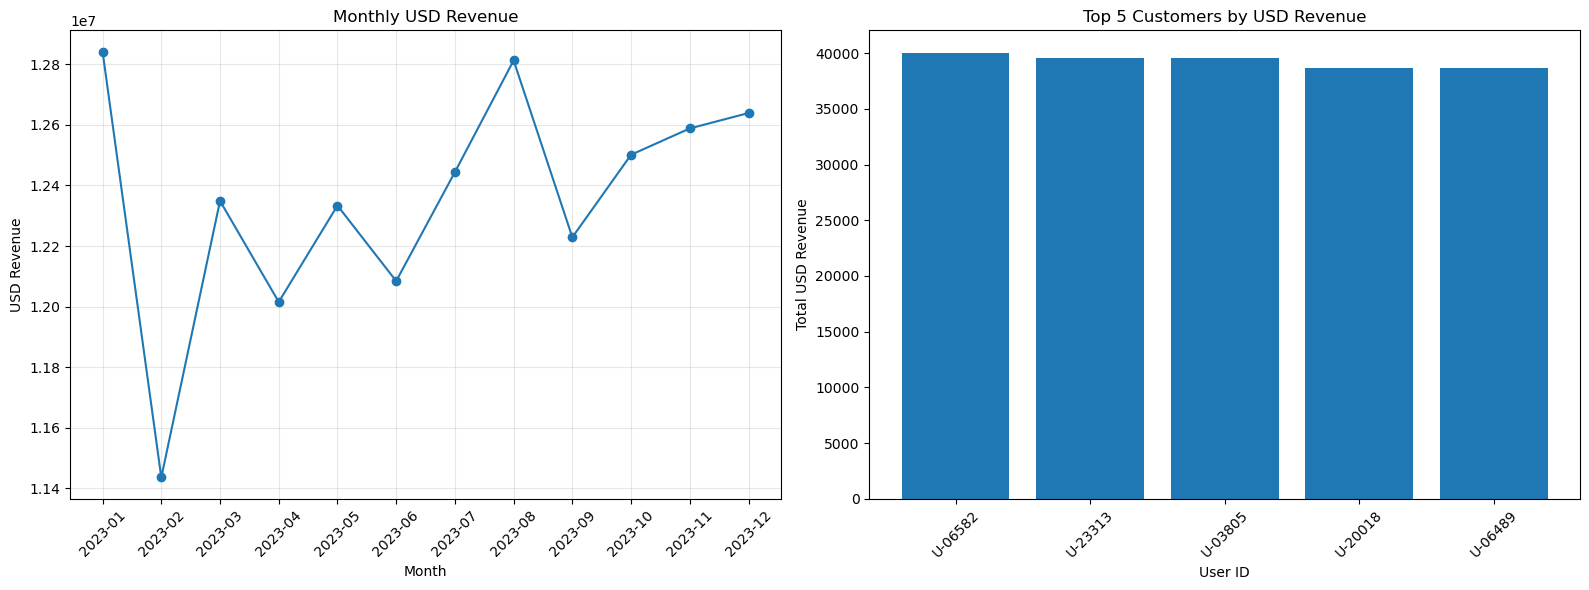

In [29]:
# ===================================================================
# PHASE 4: CFO DASHBOARD - VISUALIZATION
# ===================================================================

import matplotlib.pyplot as plt

# Create two charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------------
# Chart 1: Revenue by Month
# ---------------------------------------------------------------

axes[0].plot(
    monthly_revenue["Month"],
    monthly_revenue["USD_Revenue"],
    marker="o"
)

axes[0].set_title("Monthly USD Revenue")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("USD Revenue")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)


# ---------------------------------------------------------------
# Chart 2: Top 5 Customers
# ---------------------------------------------------------------

axes[1].bar(
    top_customers["User_ID"],
    top_customers["USD_Revenue"]
)

axes[1].set_title("Top 5 Customers by USD Revenue")
axes[1].set_xlabel("User ID")
axes[1].set_ylabel("Total USD Revenue")
axes[1].tick_params(axis="x", rotation=45)


# Overall layout
plt.tight_layout()
plt.show()

In [30]:
print("Phase 1 - Active Users:", len(df_active_users))
print("Phase 2 - Extracted Transactions:", len(extracted_data))
print("Phase 3 - Final Records:", len(df_final))

print("\nFinal Data Columns:")
print(df_final.columns.tolist())

Phase 1 - Active Users: 14183
Phase 2 - Extracted Transactions: 94902
Phase 3 - Final Records: 53899

Final Data Columns:
['Date', 'User_ID', 'Product_ID', 'Euro_Value', 'EUR_to_USD', 'user_id', 'name', 'status', 'updated_at', 'USD_Revenue', 'Month']
